# Visualization
Loads the pre-computed results from `analysis_results.pkl` (produced by `01_analysis.ipynb`) and renders all charts.

Run `01_analysis.ipynb` at least once before this notebook.

In [8]:
import pickle
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [9]:
# ── Load Analysis Results ───────────────────────────────────────────────────────
with open('analysis_results.pkl', 'rb') as f:
    results = pickle.load(f)

df = results['df']
status_counts = results['status_counts']
noshow_by_division = results['noshow_by_division']
specialty_demand = results['specialty_demand']
avg_wait = results['avg_wait']
age_dist = results['age_dist']
monthly_trend = results['monthly_trend']
print("Loaded analysis results.")

Loaded analysis results.


ValueError: x must be 1D

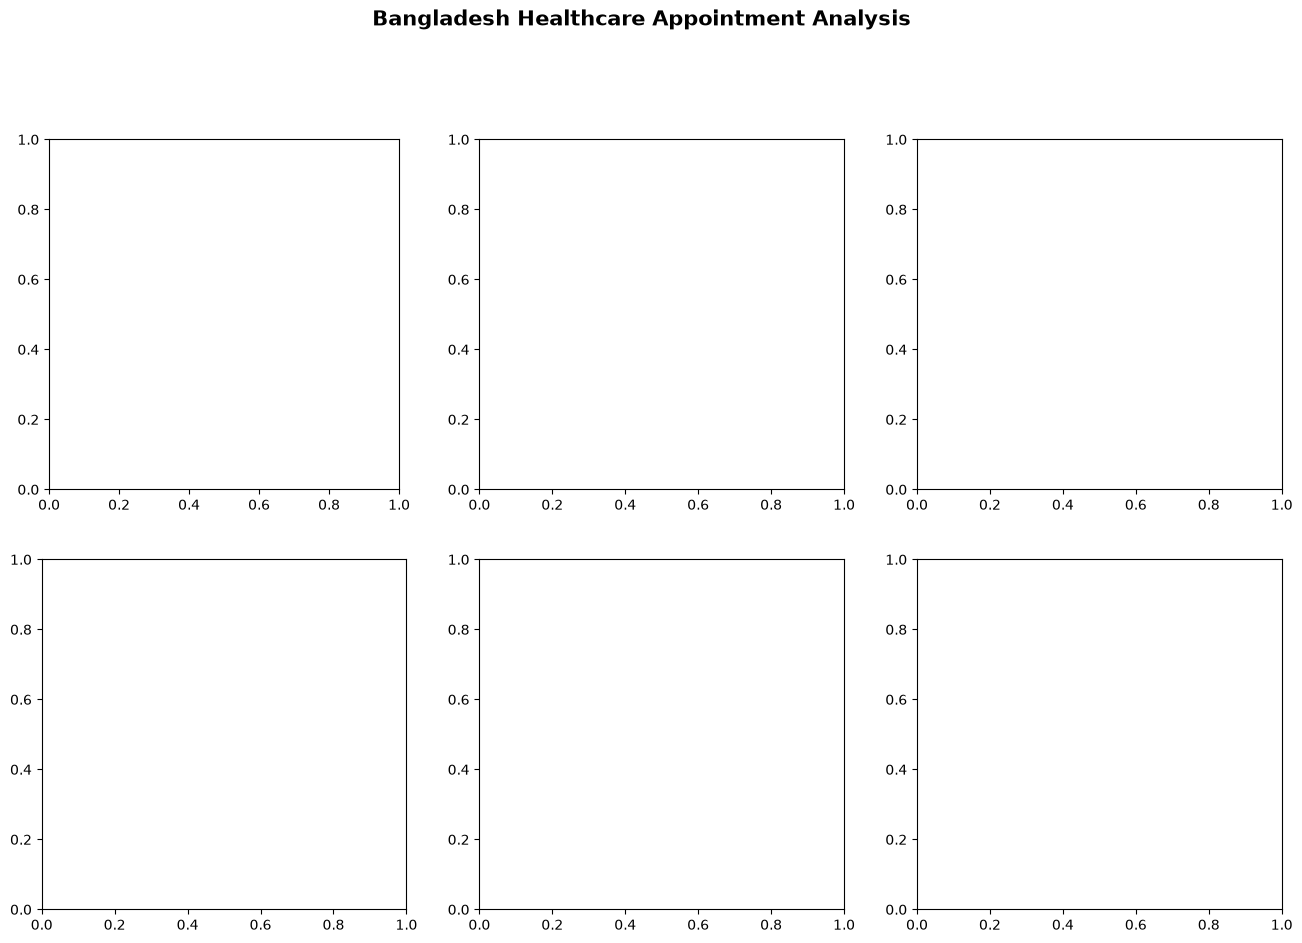

In [10]:
# ── Visualizations ─────────────────────────────────────────────────────────────
plt.close('all')  # clears out any old figures before drawing a new one

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Bangladesh Healthcare Appointment Analysis', fontsize=15, fontweight='bold', y=1.01)

colors_main = ['#2ecc71', '#e74c3c', '#e67e22']
bar_color = '#3498db'

# Plot 1 — Appointment Status
axes[0, 0].pie(
    status_counts.values,
    labels=status_counts.index,
    autopct='%1.1f%%',
    colors=colors_main,
    startangle=90
)
axes[0, 0].set_title('Appointment Status Distribution')

# Plot 2 — No-show Rate by Division
axes[0, 1].barh(
    noshow_by_division['division'],
    noshow_by_division['noshow_rate_pct'],
    color='#e74c3c'
)
axes[0, 1].set_xlabel('No-show Rate (%)')
axes[0, 1].set_title('No-show Rate by Division')

# Add value labels above each point
for i, v in enumerate(noshow_by_division['noshow_rate_pct']):
    axes[0, 1].text(v + 0.2, i, f'{v}%', va='center', fontsize=9)

# Plot 3 — Specialty Demand
axes[0, 2].barh(
    specialty_demand['doctor_specialty'],
    specialty_demand['appointments_count'],
    color=bar_color
)
axes[0, 2].set_xlabel('Number of Appointments')
axes[0, 2].set_title("Appointments by Doctor's Specialty")

# Add value labels above each point
for i, v in enumerate(specialty_demand['appointments_count']):
    axes[0, 2].text(v + 0.2, i, f'{v}', va='center', fontsize=9)

# Plot 4 — Average Wait Days
axes[1, 0].bar(
    avg_wait['doctor_specialty'],
    avg_wait['avg_wait_days'],
    color='#9b59b6'
)
axes[1, 0].set_ylabel('Avg Wait Days')
axes[1, 0].set_title('Average Wait Days by Specialty')
axes[1, 0].tick_params(axis='x', rotation=30)

# Add value labels above each point
for i, v in enumerate(avg_wait['avg_wait_days']):
    axes[1, 0].text(i, v + 0.1, f'{v:.1f}', ha='center', va='bottom', fontsize=9)

# Plot 5 — Age Group Distribution
axes[1, 1].bar(
    age_dist['age_group'],
    age_dist['count'],
    color='#1abc9c'
)
axes[1, 1].set_ylabel('Number of Patients')
axes[1, 1].set_title('Patient Age Group Distribution')
axes[1, 1].tick_params(axis='x', rotation=15)

# Add value labels above each point
for i, v in enumerate(age_dist['count']):
    axes[1, 1].text(i, v + 0.2, f'{v}', ha='center', va='bottom', fontsize=9)

# Plot 6 — Monthly Trend in 2024
trend_2024 = monthly_trend[monthly_trend['year'] == 2024]
axes[1, 2].plot(
    trend_2024['month_name'],
    trend_2024['count'],
    marker='o',
    color='#e67e22',
    linewidth=2
)
axes[1, 2].set_ylabel('Appointments')
axes[1, 2].set_title('Monthly Appointment Trend (2024)')
axes[1, 2].tick_params(axis='x', rotation=30)

# Add value labels above each point
for i, v in enumerate(trend_2024['count']):
    axes[1, 2].text(i, v + 0.15, f'{v}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('healthcare_analysis.png', dpi=150, bbox_inches='tight')
print("Chart saved as healthcare_analysis.png")